### **와인 데이터를 활용한 <span style="color:darkgreen">와인 품질</span> 예측**
---

- 도메인 : 품질 관리(QC)
- 목  표 : 와인의 품질을 예측하는 인공지능모델 개발
- 와인 도매업체인 C사에서 수입하는 와인 품질이 경쟁사 와인 품질 대비 떨어진다는 평가를 받으며 매출이 감소하고 있다.
- 계속되는 매출 부진을 만회하기 위해, C사 품질관리팀장은 수십년간 축적된 공신력 있는 와인평론가의 와인 평가 데이터를 활용해서 '와인품질등급'을 예측하는 인공지능 모델을 도입하려고 한다.
- C사는 브랜드파워가 있기 때문에, 인공지능을 활용해서 '와인품질등급'의 정확도가 개선되어 고품질의 와인만 선별하여 수입하면 매출이 빠르게 회복될 것으로 기대하고 있다.

> **<span style="color:red">다음 문항을 풀기 전에 </span>아래 코드를 실행하세요.**
>

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### **1. scikit-learn은 머신러닝에 널리 사용되는 파이썬 라이브러리입니다.**
### **scikit-learn을 사용할 수 있게 별칭(alias)을 sk로 해서 불러오세요.**
---

In [3]:
import sklearn as sk

### **2. AI 모델링을 위해 분석 및 처리할 데이터 파일을 읽어오려고 합니다.**
### **pandas로 데이터 파일을 읽어온 뒤, 데이터프레임 변수명 data 에 할당하고 첫 4개 행을 출력하세요.**

* **
- 데이터프레임 변수명 : data
- 데이터 파일명 : wine_quality_data.csv
    - csv 파일은 본 문제/답안지와 동일한 경로에 있습니다
---

In [20]:
import pandas as pd
data = pd.read_csv('wine_quality_data.csv')

In [21]:
data.head(4)

,Grade,E_title,E_country,E_province,E_region_1,E_region_2,E_winery,E_FE_vintage,E_wine_variety,E_FE_wine_kind,FE_continent,E_price,FE_points_location,FE_points_variety,FE_points_winery
0,Fail,Nicosia 2013 Vulkà Bianco (Etna),Italy,Sicily & Sardinia,Etna,-,Nicosia,2013,White Blend,white,0,NaN,90.0,87.0,87.0
1,Fail,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portugal,Douro,-,-,Quinta dos Avidagos,2011,Port,NaN,0,15.0,89.0,88.0,87.0
2,Fail,St. Julian 2013 Reserve Late Harvest Riesling ...,US,Michigan,Lake Michigan Shore,-,St. Julian,2013,Riesling,white|sparkling,1,13.0,86.0,90.0,86.0
3,Fail,Tandem 2011 Ars In Vitro Tempranillo-Merlot (N...,Spain,Northern Spain,Navarra,-,Tandem,2011,Merlot,red|rose|sparkling,0,15.0,86.0,87.0,87.0


### **3. 시각화를 통해 와인종류(E_FE_wine_kind)와 와이너리 평점(FE_points_winery)의 분포를 파악하려 합니다.**
* **
- 대상 데이터프레임 : data
- 와인종류(E_FE_wine_kind)의 분포를 보여주는 countplot 그래프를 그리세요
- 와인등급(Grade) 별 와이너리 평점(FE_points_winery)의 분포를 보여주는 histplot 그래프를 그리세요
- subplots를 활용하여 두 그래프를 가로 방향으로 나란히 그리세요
- 두 그래프의 제목을 각각 'Wine Count'와 'Winery Score'로 설정하세요<br><br>
- <font color=blue>아래 코드 셀(cell)에 있는 코드의 빈칸을 채우고 실행하세요</font>
- <font color=blue>빈칸에 들어갈 내용은 각 답안 셀(cell)에 입력하세요 (#3-1, #3-2, #3-3)</font>

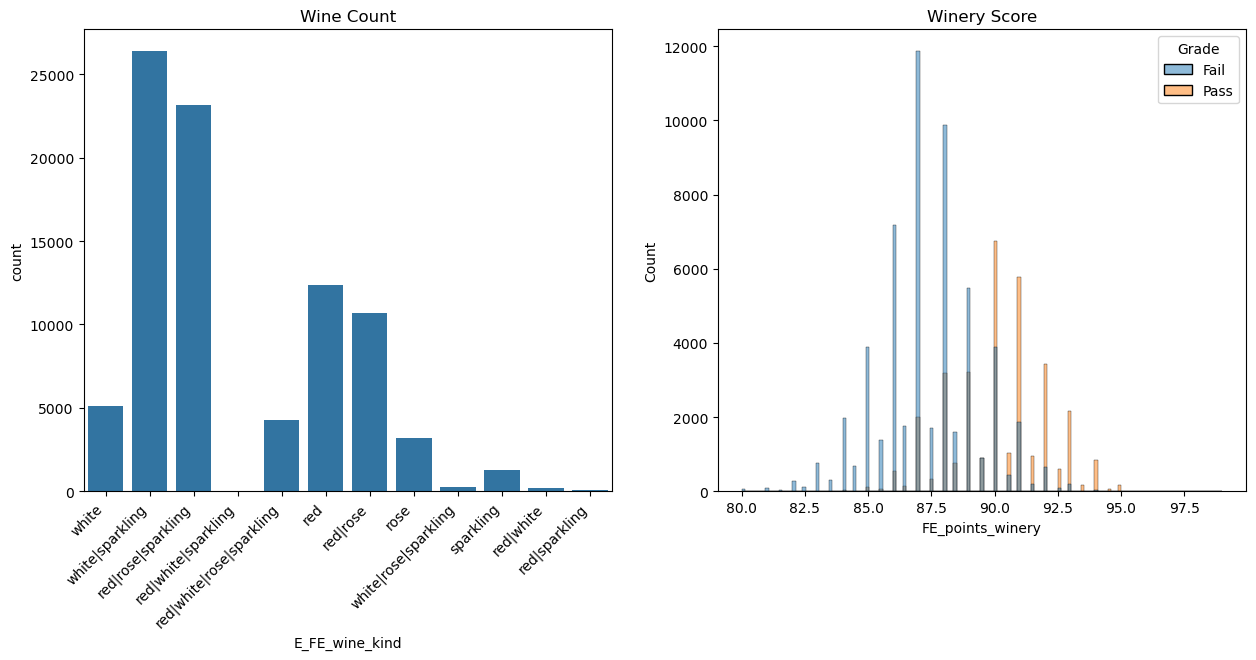

In [22]:
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 6))
sns.countplot(data = data, x = 'E_FE_wine_kind', ax = axes [0])
sns.histplot(data = data, x = 'FE_points_winery', hue = 'Grade', ax = axes[1])
axes[0].set_title('Wine Count')
axes[1].set_title('Winery Score')
plt.setp(axes[0].get_xticklabels(), rotation = 45, ha = 'right')
plt.show()

### **4. 그래프를 통해 와인품질등급(Grade) 별 와이너리 평점(FE_points_winery) 컬럼의 분포를 확인하려 합니다.**
### **아래 가이드에 따라 boxplot으로 시각화하세요.**
* **
- 대상 데이터프레임 : data
- seaborn의 boxplot으로 와이너리 평점(FE_points_winery) 컬럼의 분포를 그래프로 그리세요
- X축에는 와인품질등급(Grade)을, Y축에는 와이너리 평점(FE_points_winery)을 표시하세요
---

Text(0, 0.5, 'FE_poins_winery')

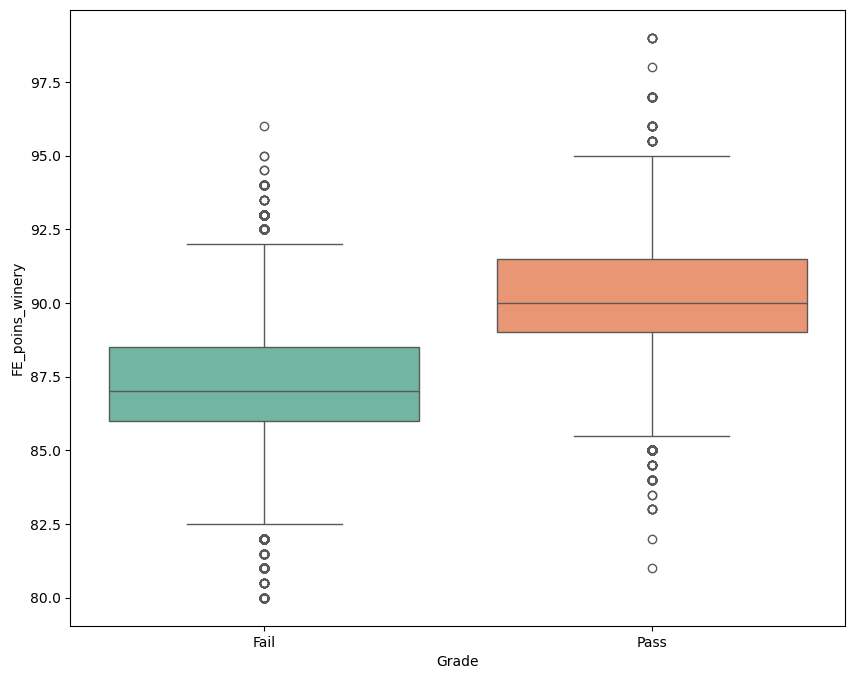

In [32]:
plt.figure(figsize = (10, 8))
sns.boxplot(data = data, x = 'Grade', y = 'FE_points_winery', hue = 'Grade', palette = 'Set2')
plt.xlabel('Grade')
plt.ylabel('FE_poins_winery')

### **5. boxplot으로 확인한 결과, 와이너리 평점(FE_points_winery) 컬럼에서 이상치가 발견되었습니다. AI모델링할때 부정적 영향이 없도록 아래 가이드에 따라 이상치를 처리하세요.**
* **
- 대상 데이터프레임 : data
- 와이너리 평점이 upperfence 값보다 큰 이상치가 있는 행(row)을 삭제하세요
- 와이너리 평점이 lowerfence 값보다 작은 이상치가 있는 행(row)을 삭제하세요
- AI모델링에 불필요한 와인이름(E_title) 컬럼을 삭제하세요
- 전처리를 적용한 데이터프레임은 data_temp라는 변수명으로 저장하세요<br><br>
- <font color=blue>아래 코드 셀(cell)에 있는 코드의 빈칸을 채우고 실행하세요</font>
- <font color=blue>빈칸에 들어갈 내용은 각 답안 셀(cell)에 입력하세요 (#5-1, #5-2)</font>
---

In [46]:
Q1 = data['FE_points_winery'].quantile(0.25)
Q3 = data['FE_points_winery'].quantile(0.75)
IQR = Q3 - Q1

lowerfence = Q1 - 1.5 * IQR
upperfence = Q3 + 1.5 * IQR

data_temp = data[(data['FE_points_winery'] <= upperfence) & (data['FE_points_winery'] >= lowerfence)]

In [47]:
data_temp = data_temp.drop(columns = 'E_title')
data_temp.reset_index(drop = True, inplace = True)

In [48]:
data_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90060 entries, 0 to 90059
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Grade               90060 non-null  object 
 1   E_country           90060 non-null  object 
 2   E_province          90060 non-null  object 
 3   E_region_1          90060 non-null  object 
 4   E_region_2          90060 non-null  object 
 5   E_winery            90060 non-null  object 
 6   E_FE_vintage        90060 non-null  int64  
 7   E_wine_variety      90060 non-null  object 
 8   E_FE_wine_kind      86314 non-null  object 
 9   FE_continent        90060 non-null  int64  
 10  E_price             83158 non-null  float64
 11  FE_points_location  90060 non-null  float64
 12  FE_points_variety   90060 non-null  float64
 13  FE_points_winery    90060 non-null  float64
dtypes: float64(4), int64(2), object(8)
memory usage: 9.6+ MB


### **6. 데이터에 결측치가 있을 경우 AI모델링의 성능이 저하될 수 있습니다. AI모델링할때 부정적 영향이 없도록 아래 가이드에 따라 결측치를 처리하세요.**
* **
- 대상 데이터프레임 : data_temp
- 결측치 개수를 확인한 후에 결측치가 있는 행을 모두 삭제하세요
- 전처리가 반영된 데이터프레임은 변수명 data_na에 저장하세요
- 결측치가 사라졌는지 확인하세요
- <font color=blue>아래 코드 셀(cell)에 있는 코드의 빈칸을 채우고 실행하세요</font>
- <font color=blue>빈칸에 들어갈 내용은 각 답안 셀(cell)에 입력하세요 (#6-1, #6-2)</font>
---

In [62]:
initial_rows = data_temp.isna().sum()
data_na = data_temp.dropna()
current_rows = data_na.isna().sum()

In [63]:
print(f'결측치 처리 전 : {initial_rows}')
print(f'결측치 처리 후 : {current_rows}')

결측치 처리 전 : Grade                    0
E_country                0
E_province               0
E_region_1               0
E_region_2               0
E_winery                 0
E_FE_vintage             0
E_wine_variety           0
E_FE_wine_kind        3746
FE_continent             0
E_price               6902
FE_points_location       0
FE_points_variety        0
FE_points_winery         0
dtype: int64
결측치 처리 후 : Grade                 0
E_country             0
E_province            0
E_region_1            0
E_region_2            0
E_winery              0
E_FE_vintage          0
E_wine_variety        0
E_FE_wine_kind        0
FE_continent          0
E_price               0
FE_points_location    0
FE_points_variety     0
FE_points_winery      0
dtype: int64


### **7. 원-핫 인코딩(One-Hot Encoding)은 범주형 데이터를 1과 0의 이진형 벡터로 변환하기 위해 사용하는 방법입니다.**
### **아래 가이드에 따라 범주형 데이터를 이진형 벡터로 변환하는 코드를 완성하세요.**
* **
- **(7-1) 아래 가이드에 따라 데이터를 처리하는 코드를 작성하고 실행하세요**
    - 대상 데이터프레임 : data_na
    - 와인종류(E_FE_wine_kind) 컬럼의 값들을 아래 기준에 따라 치환하세요
        - 'white|rose|sparkling','red|white|sparkling', 'red|white|rose|sparkling', 'red|sparkling' > 4가지 값을 'sparkling' 으로 치환
        - 'white|sparkling' > 1가지 값을 'white' 로 치환
        - 'red|rose', 'red|white', 'red|rose|sparkling' > 3가지 값을 'red' 로 치환
    - 치환 후 와인종류(E_FE_wine_kind)의 카테고리 별 개수를 출력하세요
    - <font color=blue>아래 코드 셀(cell)에 있는 코드의 빈칸을 채우고 실행하세요</font>
    - <font color=blue>빈칸에 들어갈 내용은 각 답안 셀(cell)에 입력하세요 (#7-1, #7-2)</font><br><br>
- **(7-3) 아래 가이드에 따라 결측치를 처리하고 검증하는데 에러가 나고 있습니다. 코드의 오류를 정정하세요**
    - 대상 데이터프레임 : data_na
    - 불필요한 컬럼 5개('E_province', 'E_region_1', 'E_region_2', 'E_winery', 'E_wine_variety')를 삭제하세요
    - 원-핫 인코딩 대상 컬럼은 'E_country', 'E_FE_wine_kind' 2개 입니다
    - 원-핫인코딩이 반영된 결과를 데이터프레임 변수명 data_preset에 저장하세요
    - 원-핫인코딩한 결과, 인코딩 대상 컬럼이 변환되었는지 info 함수로 검증하세요<br><br>
- **(7-4) data_na의 와인종류(E_FE_wine_kind) 중 'red'의 개수를 작성하세요**<br><br>
---

In [65]:
data_na['E_FE_wine_kind'].unique()

array(['white|sparkling', 'red|rose|sparkling', 'red|white|sparkling',
       'red|white|rose|sparkling', 'red', 'white', 'red|rose', 'rose',
       'white|rose|sparkling', 'sparkling', 'red|white', 'red|sparkling'],
      dtype=object)

In [69]:
data_na.loc[data_na['E_FE_wine_kind'].isin(['white|rose|sparkling','red|white|sparkling', 'red|white|rose|sparkling', 
                                                                               'red|sparkling']), ['E_FE_wine_kind']] = 'sparkling'

In [71]:
data_na.loc[data_na['E_FE_wine_kind'].isin(['white|sparkling']), ['E_FE_wine_kind']] = 'white'

In [72]:
data_na.loc[data_na['E_FE_wine_kind'].isin(['red|rose', 'red|white', 'red|rose|sparkling']), ['E_FE_wine_kind']] = 'red'

In [74]:
data_na['E_FE_wine_kind'].unique()

array(['white', 'red', 'sparkling', 'rose'], dtype=object)

In [76]:
print(f'카테고리 별 개수 : {data_na['E_FE_wine_kind'].value_counts()}')

카테고리 별 개수 : E_FE_wine_kind
red          42262
white        29126
sparkling     5626
rose          2910
Name: count, dtype: int64


In [80]:
data_na = data_na.drop(columns = ['E_province', 'E_region_1', 'E_region_2', 'E_winery', 'E_wine_variety'])

In [81]:
data_na.info()

<class 'pandas.core.frame.DataFrame'>
Index: 79924 entries, 2 to 90059
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Grade               79924 non-null  object 
 1   E_country           79924 non-null  object 
 2   E_FE_vintage        79924 non-null  int64  
 3   E_FE_wine_kind      79924 non-null  object 
 4   FE_continent        79924 non-null  int64  
 5   E_price             79924 non-null  float64
 6   FE_points_location  79924 non-null  float64
 7   FE_points_variety   79924 non-null  float64
 8   FE_points_winery    79924 non-null  float64
dtypes: float64(4), int64(2), object(3)
memory usage: 6.1+ MB


In [82]:
data_preset = pd.get_dummies(data = data_na, columns = ['E_country', 'E_FE_wine_kind']).copy()

In [83]:
data_preset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 79924 entries, 2 to 90059
Data columns (total 52 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Grade                             79924 non-null  object 
 1   E_FE_vintage                      79924 non-null  int64  
 2   FE_continent                      79924 non-null  int64  
 3   E_price                           79924 non-null  float64
 4   FE_points_location                79924 non-null  float64
 5   FE_points_variety                 79924 non-null  float64
 6   FE_points_winery                  79924 non-null  float64
 7   E_country_Argentina               79924 non-null  bool   
 8   E_country_Armenia                 79924 non-null  bool   
 9   E_country_Australia               79924 non-null  bool   
 10  E_country_Austria                 79924 non-null  bool   
 11  E_country_Bosnia and Herzegovina  79924 non-null  bool   
 12  E_country

In [91]:
답안07_4 = 42262

### **8. 모델링후에 모델의 성능을 평가할 수 있도록 훈련과 검증 각각에 사용할 데이터셋을 분리하려고 합니다.**
### **와인품질등급(Grade) 컬럼을 레이블값 y로, 나머지 컬럼을 피처값 X로 할당한 후 훈련데이터셋과 검증데이터셋으로 분리하세요.**
* **
- 대상 데이터프레임 : data_preset
- 훈련과 검증데이터셋 분리
  - 훈련데이터셋 레이블 : y_train, 훈련데이터셋 피처: X_train
  - 검증데이터셋 레이블 : y_valid, 검증데이터셋 피처: X_valid
  - 훈련데이터셋과 검증데이터셋 비율은 70:30으로 설정하세요
  - 훈련데이터셋과 검증데이터셋의 와인등급 비율을 동일하게 하는 옵션을 설정하세요.
  - 난수 시드는 7로 설정하세요
  - scikit-learn의 train_test_split 함수를 활용하세요
---

In [92]:
from sklearn.model_selection import train_test_split

In [93]:
X = data_preset.drop(columns = 'Grade')

In [95]:
y = data_preset['Grade']

In [101]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state = 7, stratify = y, test_size = 0.3)

### **9. 스케일링을 통해 데이터 이상치의 영향도를 낮추려고 합니다.**

* **
- **(9-1) 아래 가이드에 따라 스케일링 처리하는데 에러가 나고 있습니다. 코드의 오류를 정정하세요**
    - sklearn.preprocessing에서 StandardScaler 함수를 import하세요
    - StandardScaler 함수를 ss 변수에 지정하세요
    - 훈련데이터에 대해 StandardScaler를 학습시키고 변환을 적용하세요
    - 검증데이터에 학습된 스케일링 기준을 그대로 적용하세요
    - 스케일링된 검증데이터의 가장 큰 값을 찾고, 이를 반올림하세요<br><br>
- **(9-2) StandardSc

In [102]:
from sklearn.preprocessing import StandardScaler

In [103]:
ss = StandardScaler()

In [104]:
X_train_scaled = ss.fit_transform(X_train)
X_valid_scaled = ss.transform(X_valid)

In [107]:
round(np.max(X_valid_scaled))

237

### **10. 와인품질등급(Grade)을 예측하는 머신러닝 모델을 만들려고 합니다.** 
### **DecisionTree와 RandomForest는 여러 규칙을 순차적으로 적용하면서 독립변수 공간을 분할하는 모형으로서, 분류와 회귀 분석에 모두 사용될 수 있습니다.**

* **
- **(10-1) DecisionTree 모델의 하이퍼파라미터를 아래와 같이 구성하고, 변수에 저장하세요**
  - Cross Validation 방법론 중 GridSearchCV 사용하여 총 5회의 Cross Validation 수행
  - 트리의 최대 깊이 후보 : [3, 5, 7, 10]
  - 노드를 분할하기 위한 최소한의 샘플 데이터수(min_samples_split) 후보 : [2, 3, 5, 10]
  - GridSearchCV의 scoring 파라미터는 'accuracy', n_jobs 파라미터는 -1 로 설정
  - DecisionTree 모델의 난수 시드 : 7
  - Decision Tree 모델을 gs_dt 변수에 저장하세요
  - 앞서 분리한 훈련데이터셋으로 fit 함수를 사용해 학습시키세요<br><br>
- **(10-2) RandomForest 모델의 하이퍼파라미터를 아래와 같이 설정하고, 변수에 저장하세요**
  - Cross Validation 방법론 중 GridSearchCV 사용하여 총 5회의 Cross Validation 수행
  - 분류기 개수 후보 : [100, 200, 500]
  - 트리의 최대 깊이 후보 : [5, 10, 20]
  - 노드를 분할하기 위한 최소한의 샘플 데이터수(min_samples_split) 후보 : [2, 5, 10]
  - GridSearchCV의 scoring 파라미터는 'accuracy', n_jobs 파라미터는 -1 로 설정
  - RandomForest 모델의 난수 시드 : 7
  - Random Forest 모델을 gs_rf 변수에 저장하세요
  - 앞서 분리한 훈련데이터셋으로 fit 함수를 사용해 학습시키세요<br><br>
- **(10-3) Grid Search를 통해 찾아낸 RandomForest의 최적화된 분류기 개수는 몇 개 인가요?**<br><br>
---

In [110]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [113]:
dt_params = {
    'max_depth' : [3, 5, 7, 10],
    'min_samples_split' : [2, 3, 5, 10]
}

dt = DecisionTreeClassifier(random_state = 7)
    

In [114]:
gs_dt = GridSearchCV(
    estimator = dt,
    scoring = 'accuracy',
    param_grid = dt_params, 
    n_jobs = -1,
    cv = 5
)
    

In [115]:
gs_dt.fit(X_train_scaled, y_train)

,estimator,DecisionTreeC...andom_state=7)
,param_grid,"{'max_depth': [3, 5, ...], 'min_samples_split': [2, 3, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [124]:
rf_params = {
    'max_depth' : [5, 10, 20],
    'n_estimators' : [100, 200, 300],
    'min_samples_split' : [2, 5, 10]
}

rf = RandomForestClassifier(random_state = 7)

gs_rf = GridSearchCV(
    scoring = 'accuracy', 
    n_jobs = -1, 
    cv = 5, 
    estimator = rf,
    param_grid = rf_params
)

gs_rf.fit(X_train_scaled, y_train)
    

,estimator,RandomForestC...andom_state=7)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [121]:
print(f'Decision 최적 파라미터 : {gs_dt.best_params_}, 최고 정확도 : {gs_dt.best_score_}')

Decision 최적 파라미터 : {'max_depth': 7, 'min_samples_split': 2}, 최고 정확도 : 0.8070640184957604


In [125]:
print(f'RandomForest 최적 파라미터 : {gs_rf.best_params_}, 최고 정확도 : {gs_rf.best_score_}')

RandomForest 최적 파라미터 : {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 200}, 최고 정확도 : 0.8175026714207932


In [126]:
print(gs_rf.best_params_)


{'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 200}


In [ ]:
pd.rename(